---
title: Multivariate > Choice-based Conjoint
jupyter: python3
---

<div class="alert alert-info">Estimate attribute part-worths from choice data, where respondents pick one product from a set of alternatives.</div>

<!-- pyrsm-teaching-note: roadmap -->
## Teaching Roadmap

Choice-based conjoint (CBC) is the most widely used conjoint method in practice. Instead of rating or ranking every profile (as in ratings-based `conjoint`), respondents repeatedly choose **one** product from a small set of alternatives — exactly how people shop. CBC estimates part-worths with a **multinomial (conditional) logit** choice model.

Students should learn to (1) recognize the long "choice task" data format, (2) read part-worths and importance weights from a choice model, (3) interpret the model fit (log-likelihood, McFadden pseudo-R²), and (4) predict choice **probabilities** (market shares) for new product profiles.

In [1]:
import polars as pl
import pyrsm as rsm

In [2]:
## setup pyrsm for autoreload
%reload_ext autoreload
%autoreload 2
%aimport pyrsm

## The Chocolate-bar Choice Study

The `choc` dataset is a simulated CBC study: 200 respondents each completed 8 choice tasks, choosing one of 3 chocolate bars per task. The data are in **long** format — one row per alternative per task:

- `choice_id` — the choice-task id (the "observation"/grouping unit; each task has exactly one chosen alternative)
- `alt` — the alternative id within a task (1–3)
- `brand`, `chocolate`, `price`, `nuts` — the product attributes
- `chosen` — 1 if this alternative was chosen, else 0

In [3]:
def load_mv(name):
    """Load a multivariate example dataset from GitHub, with a local fallback."""
    url = (
        "https://github.com/radiant-ai-hub/pyrsm/raw/refs/heads/main/"
        f"examples/data/multivariate/{name}.parquet"
    )
    try:
        return pl.read_parquet(url)
    except Exception:
        from pathlib import Path

        for base in [Path.cwd(), *Path.cwd().parents]:
            p = base / "examples" / "data" / "multivariate" / f"{name}.parquet"
            if p.exists():
                return pl.read_parquet(p)
        raise


choc = load_mv("choc")
choc.head(6)

resp,choice_id,alt,brand,chocolate,price,nuts,chosen
i64,i64,i64,enum,enum,f64,enum,i64
1,1,1,"""Godiva""","""White""",4.99,"""No""",0
1,1,2,"""Hershey""","""White""",2.99,"""No""",1
1,1,3,"""Hershey""","""Milk""",3.99,"""No""",0
1,2,1,"""Godiva""","""Milk""",3.99,"""No""",0
1,2,2,"""Hershey""","""Dark""",4.99,"""Yes""",0
1,2,3,"""Lindt""","""White""",3.99,"""Yes""",1


Notice that exactly one row per `choice_id` has `chosen == 1`:

In [4]:
choc.group_by("choice_id").agg(pl.col("chosen").sum())["chosen"].unique().to_list()

[1]

## Fit the Choice Model

`cbc` fits a conditional-logit choice model. Categorical attributes are treatment-coded (the first level is the base, with part-worth 0), so the output reads just like ratings-based conjoint.

In [5]:
ch = rsm.multivariate.cbc(
    {"choc": choc},
    rvar="chosen",
    evar=["brand", "chocolate", "price", "nuts"],
    id="choice_id",
    alt="alt",
)
ch.summary()

Choice-based conjoint analysis
Data                 : choc
Response variable    : chosen
Choice-task id       : choice_id
Explanatory variables: brand, chocolate, price, nuts
Choice tasks         : 1,600
Observations         : 4,800

Conjoint part-worths:
shape: (9, 3)
┌────────────┬─────────┬────────┐
│ Attributes ┆ Levels  ┆ PW     │
│ ---        ┆ ---     ┆ ---    │
│ str        ┆ str     ┆ f64    │
╞════════════╪═════════╪════════╡
│ brand      ┆ Hershey ┆ 0.0    │
│ brand      ┆ Lindt   ┆ 0.82   │
│ brand      ┆ Godiva  ┆ 1.203  │
│ chocolate  ┆ Milk    ┆ 0.0    │
│ chocolate  ┆ Dark    ┆ 0.494  │
│ chocolate  ┆ White   ┆ -0.32  │
│ price      ┆ (slope) ┆ -0.856 │
│ nuts       ┆ No      ┆ 0.0    │
│ nuts       ┆ Yes     ┆ 0.178  │
└────────────┴─────────┴────────┘

Conjoint importance weights:
shape: (4, 2)
┌────────────┬───────┐
│ Attributes ┆ IW    │
│ ---        ┆ ---   │
│ str        ┆ f64   │
╞════════════╪═══════╡
│ brand      ┆ 0.394 │
│ chocolate  ┆ 0.267 │
│ price      ┆ 

The coefficients are the **part-worth utilities**. Positive values raise the probability that an alternative is chosen; `price` has a negative coefficient (higher price → lower choice probability). The McFadden pseudo-R² compares the model to a "random choice" baseline (values of 0.2–0.4 indicate a good fit for choice data).

## Part-worths and Importance Weights

Part-worths are reported relative to each attribute's base level (set to 0). Importance weights summarize how much each attribute drives choice — the range of its part-worths relative to the total range.

In [6]:
ch.PW

Attributes,Levels,PW
str,str,f64
"""brand""","""Hershey""",0.0
"""brand""","""Lindt""",0.82
"""brand""","""Godiva""",1.203
"""chocolate""","""Milk""",0.0
"""chocolate""","""Dark""",0.494
"""chocolate""","""White""",-0.32
"""price""","""(slope)""",-0.856
"""nuts""","""No""",0.0
"""nuts""","""Yes""",0.178


In [7]:
ch.IW

Attributes,IW
str,f64
"""brand""",0.394
"""chocolate""",0.267
"""price""",0.28
"""nuts""",0.058


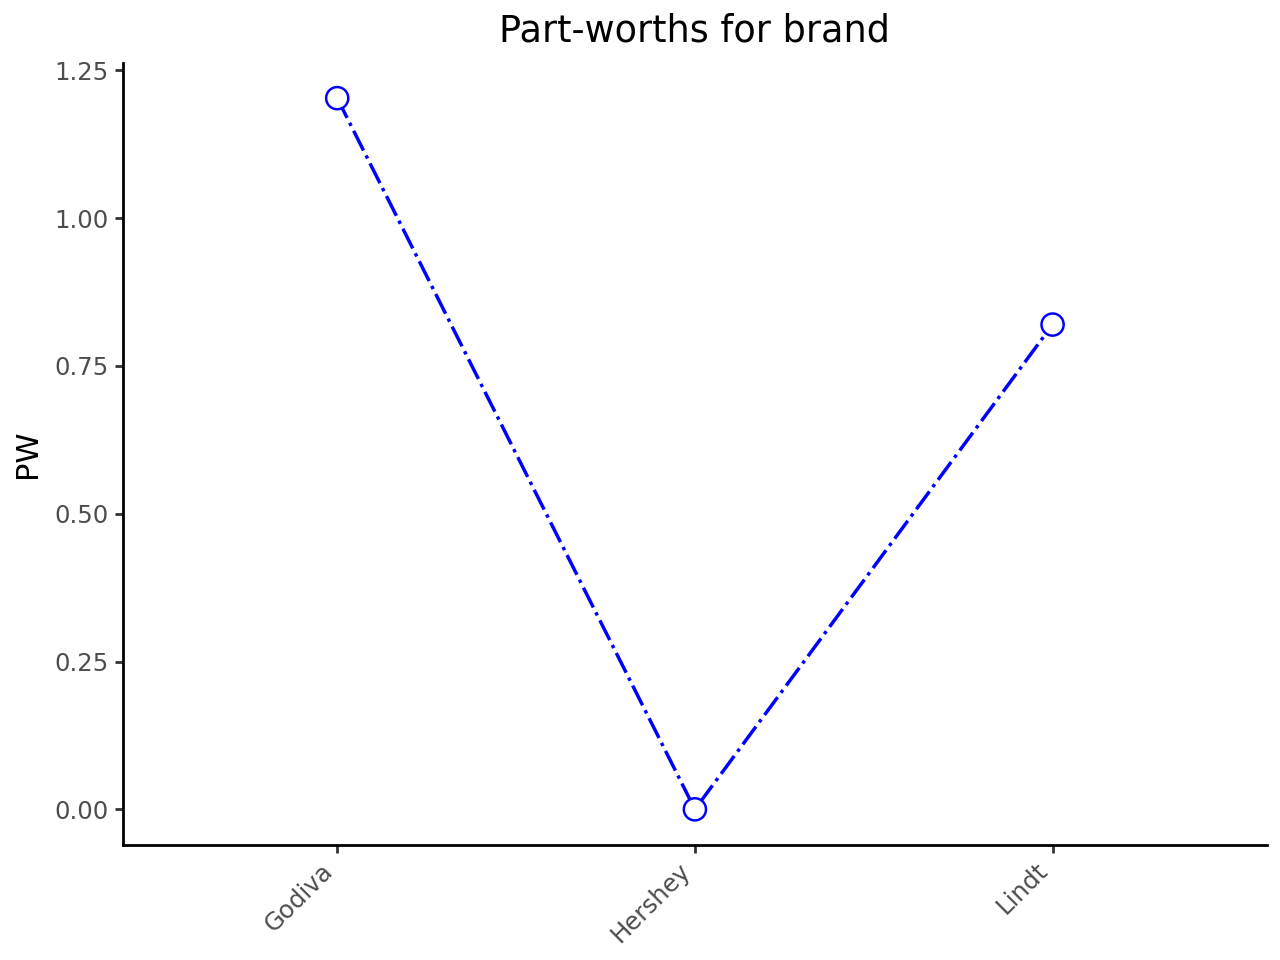

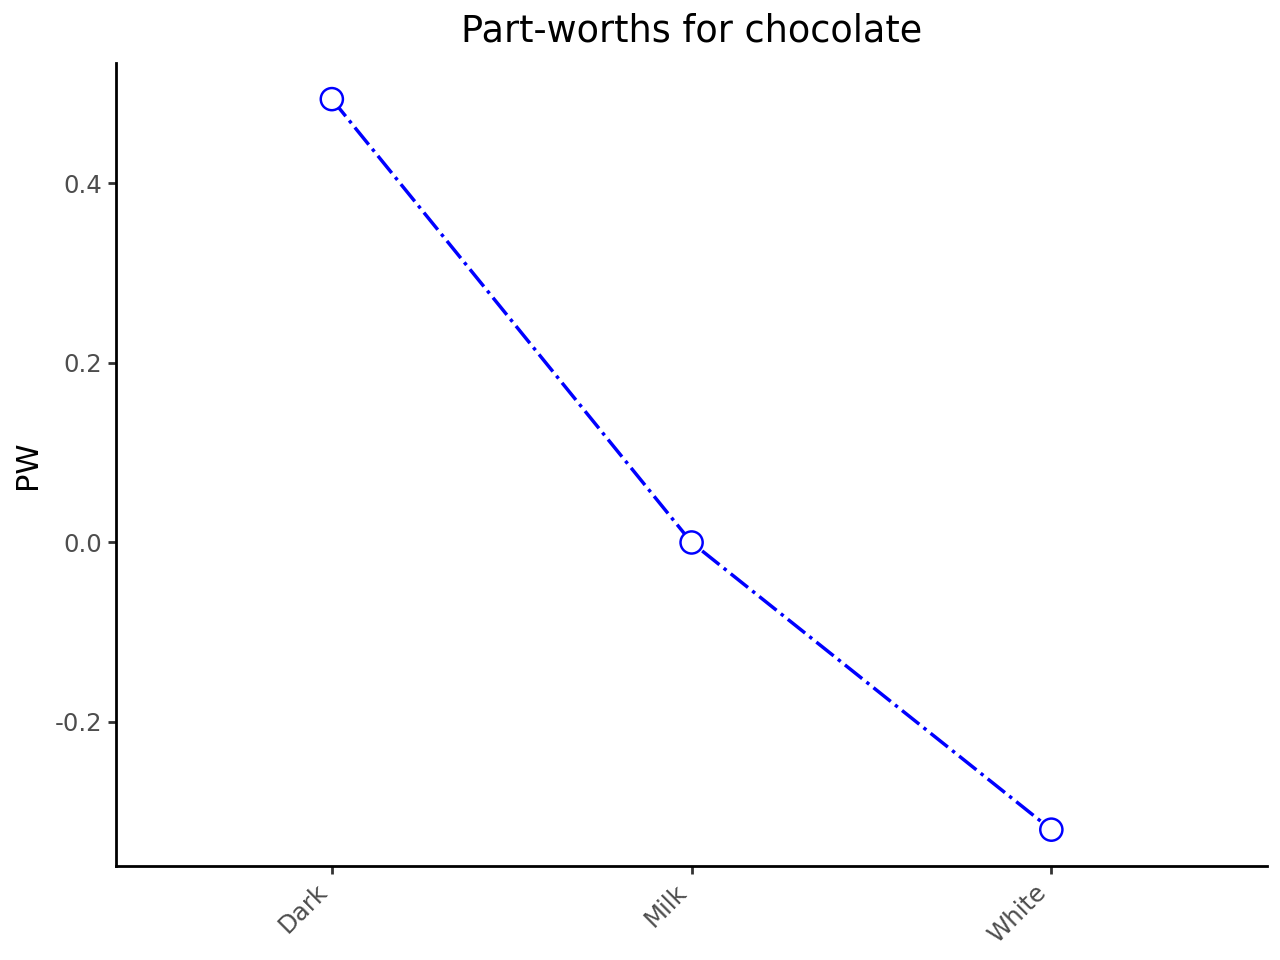

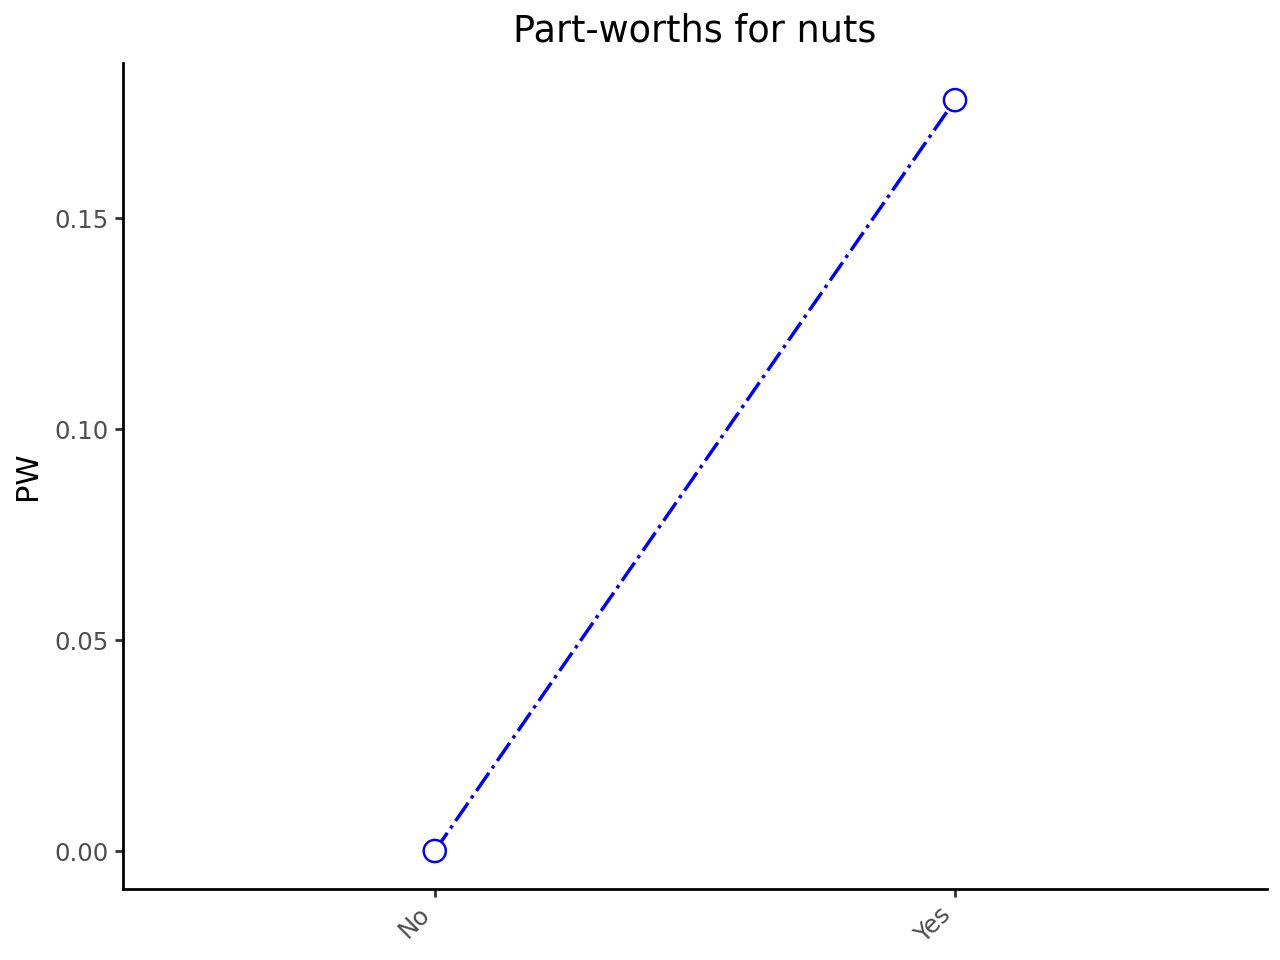

In [8]:
ch.plot(plots="pw")

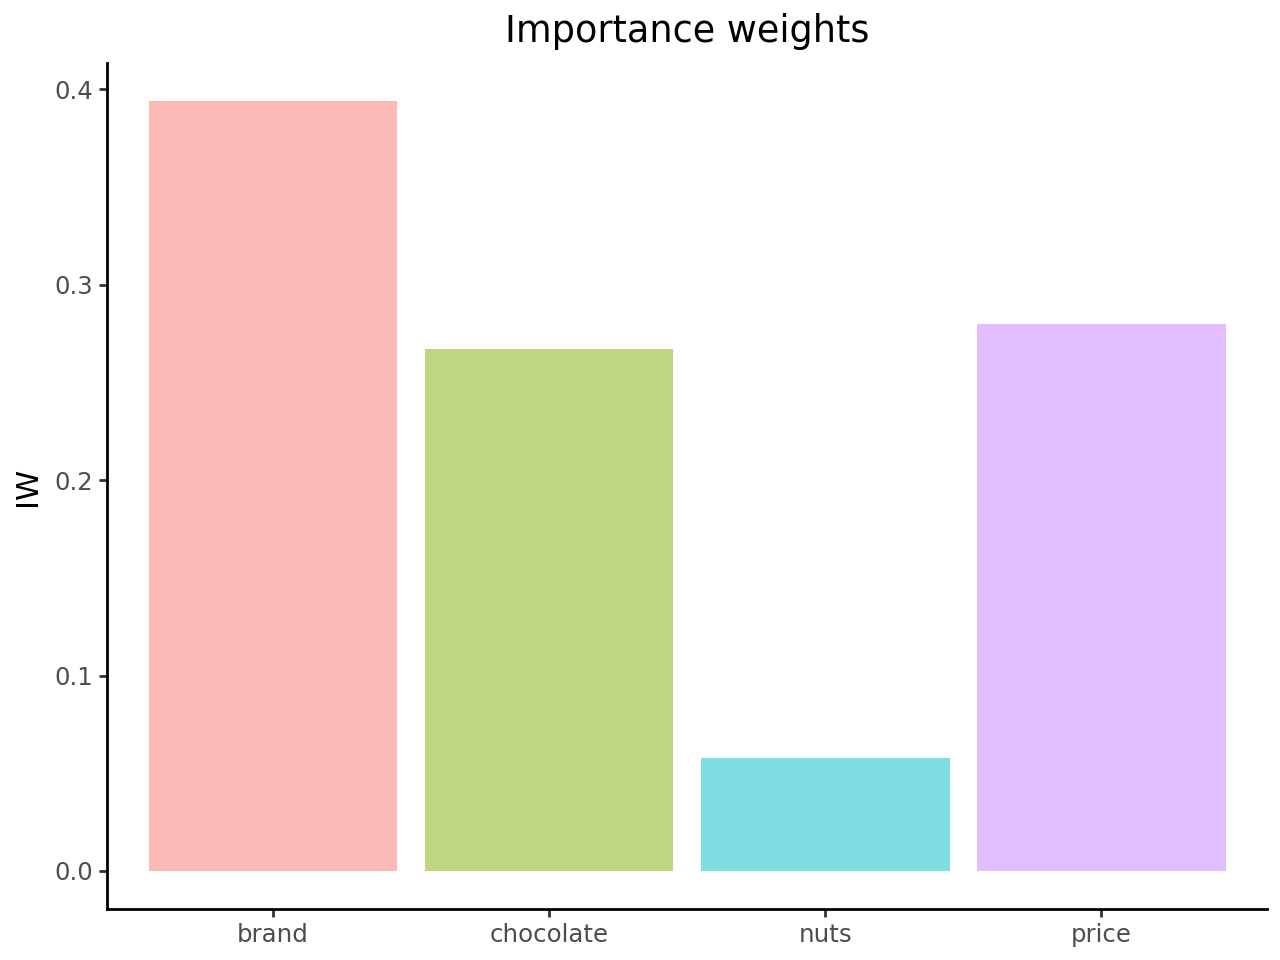

In [9]:
ch.plot(plots="iw")

## Predicting Choice Probabilities (Market Simulation)

The real payoff of CBC is **what-if** market simulation: given a set of competing products, predict the share of choices each will capture. Choice probabilities are the conditional-logit softmax of the predicted utilities *within a choice set*.

Here we pit three brands against each other, holding the other attributes fixed:

In [10]:
sim = ch.predict(
    pred_cmd={
        "brand": ["Hershey", "Lindt", "Godiva"],
        "chocolate": "Dark",
        "price": 3.99,
        "nuts": "Yes",
    }
)
sim

choice_id,alt,utility,probability
i64,i64,f64,f64
1,1,-2.742,0.151
1,2,-1.921,0.344
1,3,-1.539,0.504


The probabilities sum to 1 across the alternatives in the choice set and represent predicted market shares. Because Godiva has the largest brand part-worth, it captures the largest share.

You can also score the estimation data directly and attach the predicted probabilities:

In [11]:
pred = ch.predict()
choc.with_columns(pred["probability"]).head(6)

resp,choice_id,alt,brand,chocolate,price,nuts,chosen,probability
i64,i64,i64,enum,enum,f64,enum,i64,f64
1,1,1,"""Godiva""","""White""",4.99,"""No""",0,0.275
1,1,2,"""Hershey""","""White""",2.99,"""No""",1,0.457
1,1,3,"""Hershey""","""Milk""",3.99,"""No""",0,0.268
1,2,1,"""Godiva""","""Milk""",3.99,"""No""",0,0.543
1,2,2,"""Hershey""","""Dark""",4.99,"""Yes""",0,0.136
1,2,3,"""Lindt""","""White""",3.99,"""Yes""",1,0.321


## Discussion Prompts

Ask students: which attribute matters most for choice? How would a price cut on the weakest brand change its predicted share? How does CBC differ from ratings-based conjoint in what it asks respondents to do — and why might choice data be more realistic for forecasting market behavior?